<style>
.box{padding:12px 14px;border-radius:8px;background:#e6f2ff;color:#0b1f33} @media(prefers-color-scheme:dark){  .box{background:#0b2540;color:#e6f2ff} }
</style>
<div class="box">

Accompanying Worksheets to Class Notes, also printed in [Introduction to Computational Physics](https://www.amazon.com/Introduction-Computational-Physics-Differential-Simulations/dp/B0GJD4DNNY).

# Worksheet 20: Random Number Generators

- Demonstrate reproducibility with seeds; 
- Generate uniform and normal samples;
- Discuss pseudo-random limitations and when it matters.

In [19]:
import numpy.random as npr  # random numpy module
import matplotlib.pyplot as plt
import numpy as np

##  Random Generator with Spawning

A robust and modern approach is using a *random generator* class in Python. It supports spawning; i.e.repeatable pseudo-numbers across multiple local or distributed processes. The default [bit generator class](https://numpy.org/doc/stable/reference/random/bit_generators/index.html) is called `PCG64` (permuted congruential generator), which is a fast generator with a period of $2^{128}$. The class is initialized with a `seed` for reproducibility. We name the class object `rng`, but you can choose any name. 

```{python}
rng = npr.default_rng(seed = 521)
N = 10
x,y = rng.random(N)*2, rng.random(N)*2
```

| Function                        | Comments                   |
|:----------------------------------- |:----------------------------------- |
| `rng.random(5)`                     | Uniform floats in ([0, 1))                     |
| `rng.integers(0, 10, size=5)`       | Uniform integers over a range                  |
| `rng.choice(["a","b","c"], size=2)` | Sampling from a set       |
| `rng.standard_normal(3)`            | Standard normal draws ($N(0,1)$)            |
| `rng.normal(loc=10.0, scale=2.0, size=3)`   | Normal draws ($N(\mu,\sigma)$)   |
| `rng.shuffle(x)`                            | In-place shuffling        |
| `rng.binomial(n=10, p=0.3, size=5)`         | Binomial distribution      |
| `rng.poisson(lam=4.0, size=5)`              | Poisson  distribution     |
| `children = rng.spawn(4)`                    | Parallel simulations  |

: Commonly used methods from the random generator class.

## Random Number Limitations

- Random number generators on computers are created by algorithm and produce **pseudo-random** numbers.
- For repeatibility, you will need to **seed** the generator class.
- Pseudo-random numbers will eventually repeat. 
- Floating point has finite precision and rounding errors. 
- It is important to understand the sample size needed to generate a useful set of numbers for a particular problem.

<style>
.box{padding:12px 14px;border-radius:8px;background:#e6f2ff;color:#0b1f33} @media(prefers-color-scheme:dark){  .box{background:#0b2540;color:#e6f2ff} }
</style>
<div class="box">


## Task 1: Random Number

Create 10 random numbers between 0 and 1 using the default big generator class. Use a seed to make the random numbers reproducible.

</div>

In [20]:
# Random Number


<style>
.box{padding:12px 14px;border-radius:8px;background:#e6f2ff;color:#0b1f33} @media(prefers-color-scheme:dark){  .box{background:#0b2540;color:#e6f2ff} }
</style>
<div class="box">



## Task 2: Random Number (2)

Create 1000 random numbers in the range from 10 to 100. Then print the lowest and the highest random number from that set and make sure it is within that range.

In [21]:
# Random numbers between 10 and 100 

<style>
.box{padding:12px 14px;border-radius:8px;background:#e6f2ff;color:#0b1f33} @media(prefers-color-scheme:dark){  .box{background:#0b2540;color:#e6f2ff} }
</style>
<div class="box">

## Task 3: Normal Distribution

Create 100 and 1000 random numbers from a normal distribution with mean 0 and standard deviation 1. Plot histograms of both sets of numbers on the same graph, using different colors for each set. Include a legend to differentiate between the two sets. 

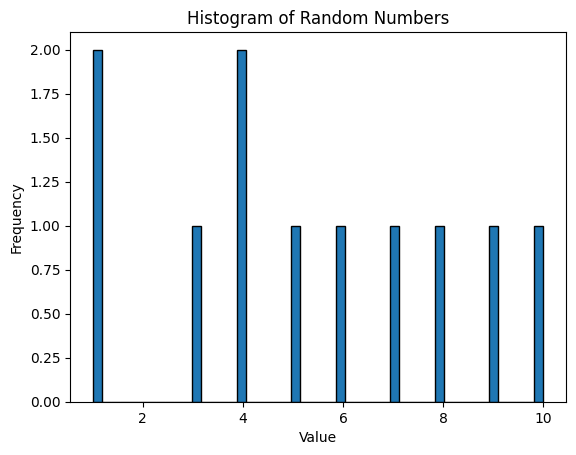

In [22]:
# your graph of random numbers as a histogram
fig, ax = plt.subplots()

# REPLACE with your random vector of numbers
rnd_vec = np.array([1,3,4,1,4,5,6,7,8,9,10])  # Example  


ax.hist(rnd_vec, bins=50, edgecolor='black')
ax.set_title('Histogram of Random Numbers')
ax.set_xlabel('Value')
ax.set_ylabel('Frequency')  
plt.show()

## Needle in Haystack Problem

The needle in the haystack problem  illustrates the challenge of locating something small in a large area. The haystack problem was mathematically introduced by [Compte de Buffon](https://en.wikipedia.org/wiki/Buffon%27s_needle_problem)  as finding the probability $p$ that a needle of length $L$ will lie across a boundary on a striped floor. The floor has long wood panels of width $t$ and the needle can either fall onto one panel or lie across the boundary of two panels. The probability of sitting on more than one panel can be expressed analytically as $p = \frac{2}{\pi}\frac{L}{t}$.  

With this interesting method you can compute $\pi$ simply by counting needles; one obtains a reasonable value for $\pi$ with only 100 -- 200 needles. That means that you can compute $\pi$ without a computer simply by tossing matches on the floor. *Buffon's algorithm* is expressed as follows:  
 
## Needle in Haystack Algorithm

1.  Get 4 boxes of matches for a total of about $N =$ 150 - 200 matches
2.  Determine the length $L$ of the average sized match
3.  Use a large piece of paper and draw horizontal lines separated by a distance $L$
4.  Randomly drop the matches onto the card box
5.  Count the number of matches $N_L$ on a line to determine $p = N_L / N$
6.  Calculate $\pi \approx \frac{2}{p}$
 

In data mining, finding rare events in large data sets efficiently is a modern computational problem. An example is fraud detection in financial transactions. It is important to find the few anomalies in these money exchanges without creating false positives. This is an example for a machine learning algorithm that uses a statistical model trained on properties for each transaction.

<style>
.box{padding:12px 14px;border-radius:8px;background:#e6f2ff;color:#0b1f33} @media(prefers-color-scheme:dark){  .box{background:#0b2540;color:#e6f2ff} }
</style>
<div class="box">

## Step 4: Solve the Needle in the Haystack Problem

Implement the algorithm for the *Needle in Haystack*, and choose the following parameters:

* N = 200
* L = 10 cm

Calculate $N_L$ and compute $p$.

To implement the algorithm, do the following (best to make a drawing):

1) generate a grid with lines L horizontally spaced
2) generate a position (x,y) randomly (center point of needle)
3) generate a random angle $\theta$
4) calculate $d = L/2 \sin(\theta)$ (distance up or down from needle center)
5) calculate distance $r$ from nearest line (either top is closer or bottom)
6) if $d > r$, then the needle is on the line, otherwise not
7) repeat for all needles

In [23]:
# Add your code for the Needle Haystack Problem 

<style>
.box{padding:12px 14px;border-radius:8px;background:#e6f2ff;color:#0b1f33} @media(prefers-color-scheme:dark){  .box{background:#0b2540;color:#e6f2ff} }
</style>
<div class="box">

## Step 5: Convergence Test

Find the number $N$ needed to solve for $\pi = 3.142 \pm 0.001$.

In [24]:
# your code


<style>
.box{padding:12px 14px;border-radius:8px;background:#e6f2ff;color:#0b1f33} @media(prefers-color-scheme:dark){  .box{background:#0b2540;color:#e6f2ff} }
</style>
<div class="box">

## Optional: Graph the Result

Plot the grid with the lines and also graph all the needles, use two colors for those that cross the line and those that do not.

The End.